<style>
.jp-Notebook .jp-MarkdownCell,
.text_cell_render {
    font-size: 14px;
    line-height: 1.38;
}
.jp-CodeCell .cm-editor,
.jp-CodeCell pre,
.code_cell .CodeMirror {
    font-size: 13px !important;
    line-height: 1.30 !important;
}
</style>

# ECON 422: Macroeconomics & Machine Learning

### Web Scraping

This notebook practices three common tasks:

1. **Download data** — Penn World Table
2. **Request images with user-set parameters** — NASA GIBS
3. **Read and parse HTML** — Wikipedia Contents

Outputs are saved under `downloaded_materials/`.

In [2]:
%pip install beautifulsoup4

from pathlib import Path
import re, time, requests
import pandas as pd
from bs4 import BeautifulSoup
from IPython.display import display, Image as IPythonImage

BASE_DIR = Path.cwd() / "downloaded_materials"
PWT_DIR   = BASE_DIR / "pwt_data"
IMAGE_DIR = BASE_DIR / "images"
WIKI_DIR  = BASE_DIR / "wikipedia_structure"

for folder in [PWT_DIR, IMAGE_DIR, WIKI_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Reuse one web session for all requests.
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

print(BASE_DIR.resolve())


   ---------------------------------------- 2/2 [beautifulsoup4]

Note: you may need to restart the kernel to use updated packages.
C:\Users\mbadi\Documents\ECON422_MatthewBadillo\downloaded_materials


## 1. Download PWT 11.0

**Method:** direct file download  
**HTML used?** No

The URL points directly to a file:

```text
file URL
   ↓
HTTP request
   ↓
Excel bytes
   ↓
save as .xlsx
   ↓
pandas reads the file
```

So Python does **not** need to read a webpage first.

In [4]:
PWT_URL = "https://dataverse.nl/api/access/datafile/554105"
PWT_FALLBACK = "https://raw.githubusercontent.com/jivizcaino/PWT10.1/main/pwt110.xlsx"

pwt_file = PWT_DIR / "pwt110.xlsx"

def download_file(url, path):
    # GET asks the server to send the file at this URL.
    r = session.get(url, timeout=90)
    r.raise_for_status()

    # .xlsx files are ZIP-based and normally start with b"PK".
    # This check helps detect an HTML error/verification page.
    if path.suffix == ".xlsx" and not r.content.startswith(b"PK"):
        raise RuntimeError("The server did not return an Excel file.")

    # r.content contains the downloaded binary file bytes.
    path.write_bytes(r.content)

if not pwt_file.exists():
    try:
        download_file(PWT_URL, pwt_file)
    except Exception:
        download_file(PWT_FALLBACK, pwt_file)

# Now read the local Excel file.
%pip install openpyxl

pwt = pd.read_excel(
    pwt_file,
    sheet_name="Data",
    engine="openpyxl"
)

# Save a CSV copy for easier later use.
pwt.to_csv(PWT_DIR / "pwt110_data.csv", index=False)

print("Shape:", pwt.shape)
display(pwt.head())


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.
Shape: (13693, 51)


,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,ABW,Aruba,Aruban Guilder,1950,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,Aruban Guilder,1951,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,Aruban Guilder,1952,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,Aruban Guilder,1953,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,Aruban Guilder,1954,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Download NASA satellite images

**Method:** parameterized web-service request  
**HTML used?** No

Instead of opening a webpage, we send parameters directly to NASA's image service:

```text
date + location + layer + image size
                 ↓
            WMS request
                 ↓
          NASA GIBS server
                 ↓
             PNG image
```

Try changing `DATES`, `BBOX`, or `LAYER`.

2020-09-09


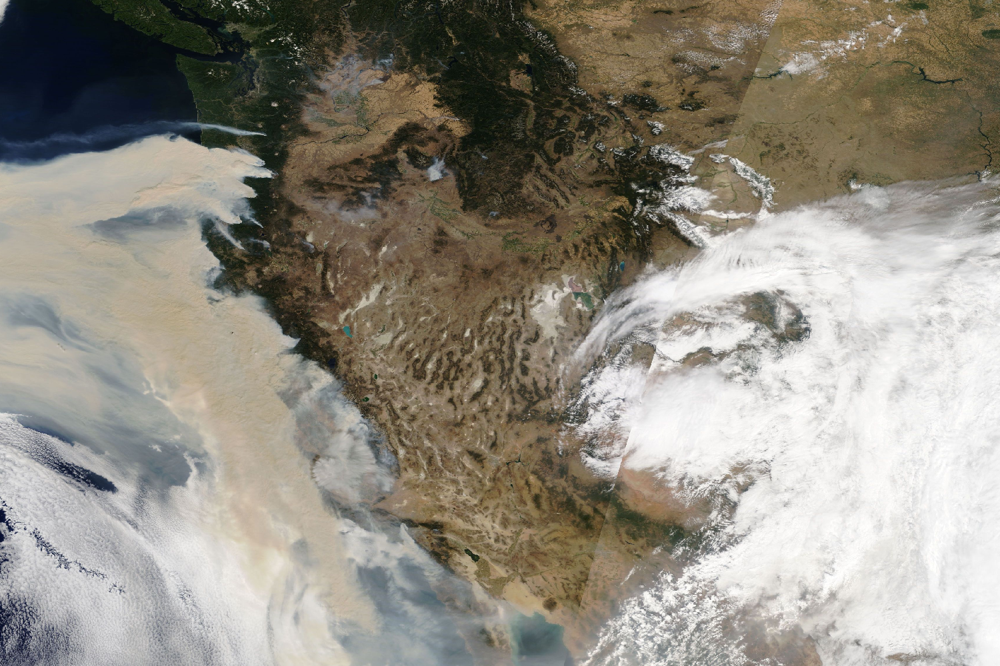

2020-09-10


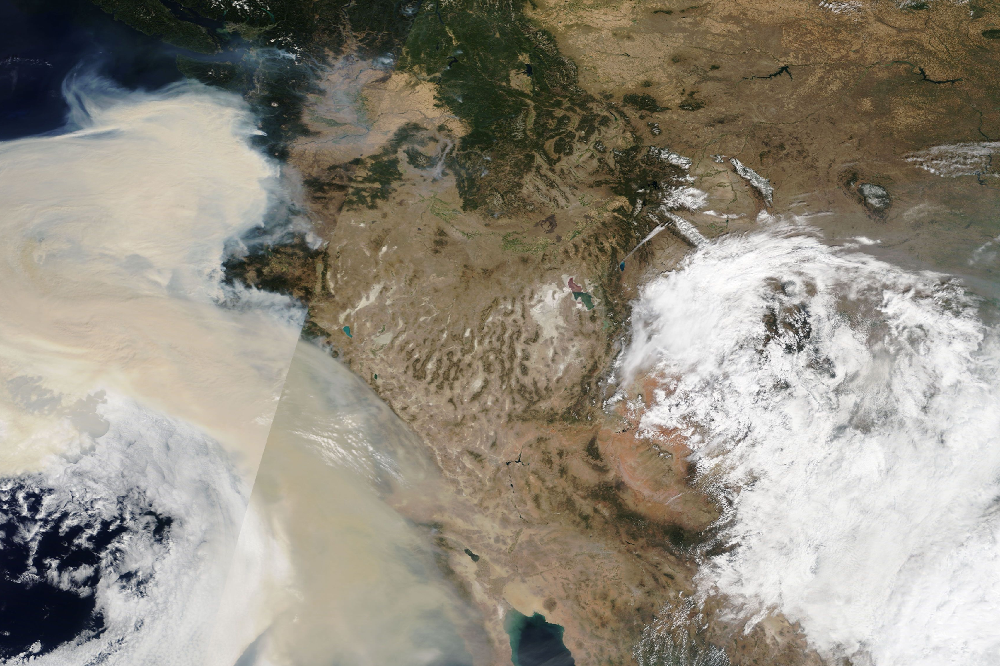

2020-09-11


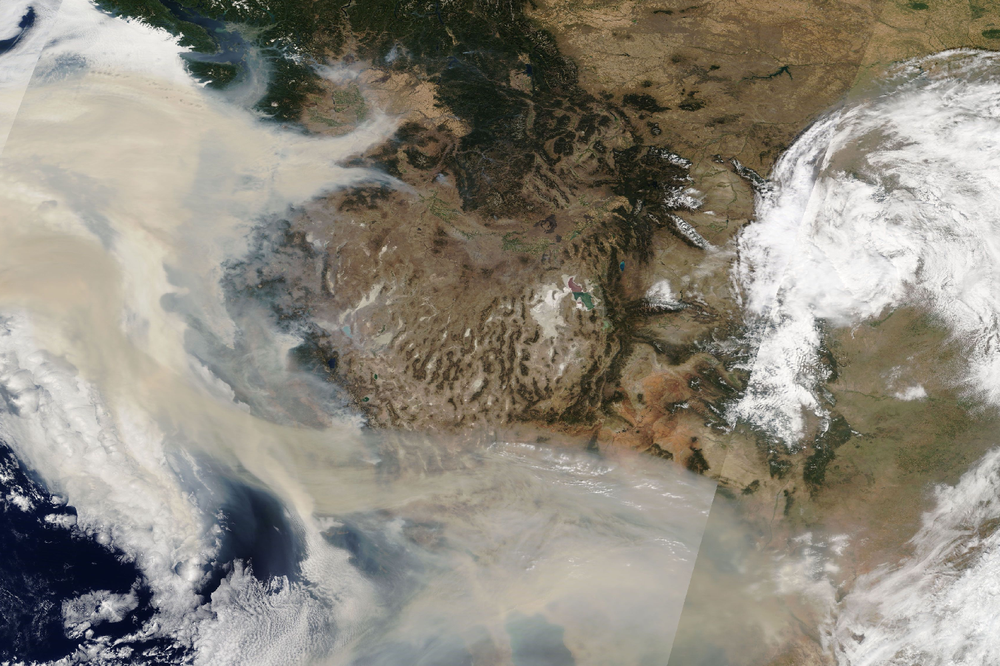

In [5]:
GIBS_WMS = "https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi"

# USER-SET PARAMETERS
LAYER = "MODIS_Terra_CorrectedReflectance_TrueColor"
BBOX = (-130, 30, -100, 50)   # min lon, min lat, max lon, max lat
DATES = ["2020-09-09", "2020-09-10", "2020-09-11"]

for date in DATES:

    # These parameters describe the image we want NASA to return.
    params = {
        "SERVICE": "WMS",
        "REQUEST": "GetMap",   # ask the WMS server for a rendered map/image
        "VERSION": "1.1.1",
        "LAYERS": LAYER,
        "STYLES": "",
        "FORMAT": "image/png",
        "TRANSPARENT": "FALSE",
        "SRS": "EPSG:4326",    # longitude/latitude coordinate system
        "BBOX": ",".join(map(str, BBOX)),
        "WIDTH": 1500,
        "HEIGHT": 1000,
        "TIME": date,
    }

    image_file = IMAGE_DIR / f"NASA_{date}.png"

    if not image_file.exists():
        # params=... adds our choices to the web-service request.
        r = session.get(GIBS_WMS, params=params, timeout=120)
        r.raise_for_status()

        # NASA returns image bytes, not HTML.
        image_file.write_bytes(r.content)

        time.sleep(0.5)

    print(date)
    display(IPythonImage(filename=str(image_file), width=750))

## 3. Extract Wikipedia's Contents

**Method:** HTML reading + parsing  
**HTML used?** **Yes**

Here the information we want is inside the webpage structure:

```text
Wikipedia URL
     ↓
download HTML
     ↓
BeautifulSoup parses HTML
     ↓
find Contents elements
     ↓
extract section numbers + titles
```

`BeautifulSoup(..., "html.parser")` **parses** the raw HTML into a searchable structure.

In [6]:
WIKI_URL = "https://en.wikipedia.org/wiki/Economics"

# Download the webpage.
r = session.get(WIKI_URL, timeout=60)
r.raise_for_status()

# r.text contains the webpage HTML as text.
html = r.text

# Save the raw HTML so it can also be inspected locally.
(WIKI_DIR / "economics_page.html").write_text(
    html,
    encoding="utf-8"
)

# HTML PARSING:
# convert raw HTML text into a searchable BeautifulSoup structure.
soup = BeautifulSoup(html, "html.parser")

# CSS selector:
# "#" means an element with this HTML id.
toc = soup.select_one("#mw-panel-toc-list")

rows = []

for li in toc.find_all("li", class_="vector-toc-list-item"):

    # recursive=False avoids accidentally selecting a subsection's link.
    link = li.find("a", class_="vector-toc-link", recursive=False)
    if link is None:
        continue

    # Extract the visible section number, e.g. 2.6.1.
    number_tag = link.select_one(".vector-toc-numb")
    if number_tag is None:   # skip "(Top)"
        continue

    number = number_tag.get_text(strip=True)

    # Extract the full visible TOC text.
    full_text = link.select_one(".vector-toc-text").get_text(" ", strip=True)

    # Remove the number from the beginning, leaving only the title.
    title = re.sub(
        rf"^{re.escape(number)}\s*",
        "",
        full_text
    ).strip()

    # Number of periods tells us the hierarchy level:
    # 2 -> level 1, 2.6 -> level 2, 2.6.1 -> level 3.
    rows.append({
        "number": number,
        "level": number.count(".") + 1,
        "title": title,
    })

contents = pd.DataFrame(rows)
display(contents.head(20))

,number,level,title
0,1,1,Definitions of economics
1,2,1,History of economic thought
2,2.1,2,From antiquity through the physiocrats
3,2.2,2,Classical political economy
4,2.3,2,Marxian economics
5,2.4,2,Neoclassical economics
6,2.5,2,Keynesian economics
7,2.6,2,Post-WWII economics
8,2.6.1,3,Monetarism
9,2.6.2,3,New classical economics


In [7]:
# Print the Contents list with indentation.
lines = []

for row in contents.itertuples(index=False):
    indent = "    " * (row.level - 1)
    line = f"{indent}{row.number} {row.title}"
    print(line)
    lines.append(line)

# Save the extracted structure.
contents.to_csv(
    WIKI_DIR / "economics_contents.csv",
    index=False
)

(WIKI_DIR / "economics_contents.txt").write_text(
    "\n".join(lines),
    encoding="utf-8"
)

1 Definitions of economics
2 History of economic thought
    2.1 From antiquity through the physiocrats
    2.2 Classical political economy
    2.3 Marxian economics
    2.4 Neoclassical economics
    2.5 Keynesian economics
    2.6 Post-WWII economics
        2.6.1 Monetarism
        2.6.2 New classical economics
        2.6.3 New Keynesians
        2.6.4 New neoclassical synthesis
        2.6.5 After the 2008 financial crisis
    2.7 Other schools and approaches
3 Methodology
    3.1 Theoretical research
    3.2 Empirical research
4 Microeconomics
    4.1 Production, cost, and efficiency
    4.2 Specialisation
    4.3 Supply and demand
    4.4 Firms
    4.5 Uncertainty and game theory
    4.6 Market failure
    4.7 Welfare
5 Macroeconomics
    5.1 Growth
    5.2 Business cycle
    5.3 Unemployment
    5.4 Money and monetary policy
    5.5 Fiscal policy
    5.6 Inequality
6 Other branches of economics
    6.1 Public economics
    6.2 International economics
    6.3 Labour economics
  

1268

## Takeaway

- **PWT:** URL directly returns a file — no HTML parsing.
- **NASA:** parameters are sent to a web service, which returns an image — no HTML parsing.
- **Wikipedia:** the webpage HTML itself contains the structure, so we download and parse HTML.

For practice, change the NASA parameters and try another Wikipedia page.